In [ ]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib joblib

## 2. Import libraries

In [1]:
import json
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.utils.class_weight import compute_sample_weight
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option("display.max_columns", None)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1784575186.484589 1548700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784575186.487829 1548700 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784575186.967965 1548700 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784575189.791000 1548700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 3. Load the dataset

In [2]:
DATA_PATH = "newcomer_ontario_enriched.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 6,900
Columns: 26


,age,sex,admission_category,province,world_region,speaks_official_language,education_level,family_size,field_of_study,previous_occupation,occupation_category,years_of_experience,teer_category,credential_recognition_status,regulated_profession,employment_probability,employed,employment_category,employment_occupation,employment_sector,occupationally_downgraded,annual_income,months_to_employment,rent_to_income_ratio,housing_affordable,affordability_score
0,35,M,Skilled Worker,Ontario,South Asia,1,University,1,Economics,HR Specialist,"Business, Finance & Administration",8,TEER 1,Not Recognized,0,0.871441,1,Sales & Service,Cashier,Accommodation & Food Services,1,21900.0,7,1.15,0,0.436
1,43,M,Skilled Worker,Ontario,South Asia,0,High School,4,General Studies,Administrative Officer,"Business, Finance & Administration",20,TEER 1,Fully Recognized,0,0.832544,1,"Business, Finance & Administration",Accountant,Public Administration,0,63300.0,2,0.40,0,0.706
2,33,M,Skilled Worker,Ontario,South Asia,1,University,3,Business Administration,Administrative Officer,"Business, Finance & Administration",2,TEER 1,Fully Recognized,0,0.879082,1,"Business, Finance & Administration",Administrative Officer,Professional Services,0,91400.0,2,0.28,1,0.861
3,42,M,Skilled Worker,Ontario,South Asia,1,College,3,Business Administration,Restaurant Manager,Management,15,TEER 0,Fully Recognized,0,0.881192,1,Management,Restaurant Manager,Accommodation & Food Services,0,78000.0,4,0.32,0,0.800
4,27,M,Skilled Worker,Ontario,South Asia,1,University,1,Mathematics,Mechanical Engineer,Natural & Applied Sciences,2,TEER 1,Not Assessed,0,0.870317,1,"Trades, Transport & Equipment Operators",Electrician,Construction,1,31300.0,1,0.81,0,0.511


## 4. Choose the ProfileEncoder inputs

Only information that would be available when the user fills out the app form is used as input.

We do not use employment, income, housing or other outcome columns as inputs because that would allow the model to see information it is supposed to predict.

In [3]:
FEATURES = [
    "age",
    "sex",
    "admission_category",
    "world_region",
    "speaks_official_language",
    "education_level",
    "family_size",
    "field_of_study",
    "previous_occupation",
    "occupation_category",
    "years_of_experience",
    "teer_category",
    "credential_recognition_status",
    "regulated_profession",
]

NUMERIC_FEATURES = [
    "age",
    "speaks_official_language",
    "family_size",
    "years_of_experience",
    "regulated_profession",
]

CATEGORICAL_FEATURES = [
    "sex",
    "admission_category",
    "world_region",
    "education_level",
    "field_of_study",
    "previous_occupation",
    "occupation_category",
    "teer_category",
    "credential_recognition_status",
]

TARGET_EMPLOYMENT = "employed"
TARGET_INCOME = "annual_income"
TARGET_CATEGORY = "employment_category"

print("Number of input columns:", len(FEATURES))
print("\nInput columns:")
for column in FEATURES:
    print(" -", column)

Number of input columns: 14

Input columns:
 - age
 - sex
 - admission_category
 - world_region
 - speaks_official_language
 - education_level
 - family_size
 - field_of_study
 - previous_occupation
 - occupation_category
 - years_of_experience
 - teer_category
 - credential_recognition_status
 - regulated_profession


## 5. Check the selected columns

In [4]:
required_columns = (
    FEATURES
    + [TARGET_EMPLOYMENT, TARGET_INCOME, TARGET_CATEGORY]
)

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"These required columns are missing: {missing_columns}"
    )

print("Missing values in selected columns:")
display(df[required_columns].isna().sum().to_frame("missing_values"))

print("\nEmployment distribution:")
display(df[TARGET_EMPLOYMENT].value_counts().rename("count").to_frame())

print("\nEmployment-category distribution:")
display(df[TARGET_CATEGORY].value_counts().rename("count").to_frame())

Missing values in selected columns:


,missing_values
age,0
sex,0
admission_category,0
world_region,0
speaks_official_language,0
education_level,0
family_size,0
field_of_study,0
previous_occupation,0
occupation_category,0



Employment distribution:


,count
employed,
1,5390
0,1510



Employment-category distribution:


,count
employment_category,
Not Employed,1510
Sales & Service,1419
"Trades, Transport & Equipment Operators",962
Manufacturing & Utilities,939
Natural & Applied Sciences,780
"Business, Finance & Administration",408
Health,388
Management,210
"Education, Law & Social Services",200


## 6. Prepare the three training targets

The neural network has three outputs:

1. `employment_output` predicts whether the newcomer is employed.
2. `income_output` predicts annual income.
3. `category_output` predicts the post-landing employment category only for employed newcomers.

Annual income is converted with `log1p` before scaling. This reduces the effect of very large income values.

In [5]:
X = df[FEATURES].copy()

y_employment = df[TARGET_EMPLOYMENT].astype("float32").to_numpy()

# The category head learns only from employed newcomers.
# "Not Employed" is handled by the separate employment head.
employed_category_mask = df[TARGET_EMPLOYMENT] == 1

category_encoder = LabelEncoder()
category_encoder.fit(
    df.loc[
        employed_category_mask,
        TARGET_CATEGORY,
    ].astype(str)
)

number_of_categories = len(category_encoder.classes_)

# Create empty category targets for every row.
# Only employed rows receive a real category label.
y_category_integer = np.zeros(len(df), dtype=int)

y_category = np.zeros(
    (len(df), number_of_categories),
    dtype="float32",
)

employed_indices = np.where(
    employed_category_mask.to_numpy()
)[0]

encoded_categories = category_encoder.transform(
    df.loc[
        employed_category_mask,
        TARGET_CATEGORY,
    ].astype(str)
)

y_category_integer[employed_indices] = encoded_categories

y_category[employed_indices] = keras.utils.to_categorical(
    encoded_categories,
    num_classes=number_of_categories,
)

print("Employment target shape:", y_employment.shape)
print("Category target shape:", y_category.shape)
print("Number of employment categories:", number_of_categories)

print("\nCategory labels:")
for index, label in enumerate(category_encoder.classes_):
    print(index, "=", label)

Employment target shape: (6900,)
Category target shape: (6900, 9)
Number of employment categories: 9

Category labels:
0 = Arts, Culture & Recreation
1 = Business, Finance & Administration
2 = Education, Law & Social Services
3 = Health
4 = Management
5 = Manufacturing & Utilities
6 = Natural & Applied Sciences
7 = Sales & Service
8 = Trades, Transport & Equipment Operators


## 7. Split the dataset

The split is done before fitting the preprocessing tools.

This keeps information from the validation and test sets out of the training process.

In [6]:
row_indices = np.arange(len(df))

train_indices, test_indices = train_test_split(
    row_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=df[TARGET_EMPLOYMENT],
)

train_indices, validation_indices = train_test_split(
    train_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=df.iloc[train_indices][TARGET_EMPLOYMENT],
)

print("Training rows:", len(train_indices))
print("Validation rows:", len(validation_indices))
print("Test rows:", len(test_indices))

Training rows: 4416
Validation rows: 1104
Test rows: 1380


## 8. Prepare the input features

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(
    X.iloc[train_indices]
).astype("float32")

X_validation = preprocessor.transform(
    X.iloc[validation_indices]
).astype("float32")

X_test = preprocessor.transform(
    X.iloc[test_indices]
).astype("float32")

print("Processed training shape:", X_train.shape)
print("Processed validation shape:", X_validation.shape)
print("Processed test shape:", X_test.shape)

Processed training shape: (4416, 116)
Processed validation shape: (1104, 116)
Processed test shape: (1380, 116)


## 9. Prepare the income target

Income is learned only from employed rows.

Unemployed rows receive an income sample weight of zero, so they do not affect the income loss.

In [8]:
income_scaler = StandardScaler()

employed_train_mask = (
    df.iloc[train_indices][TARGET_EMPLOYMENT].to_numpy() == 1
)

train_income_log = np.log1p(
    df.iloc[train_indices][TARGET_INCOME].to_numpy()
).reshape(-1, 1)

income_scaler.fit(
    train_income_log[employed_train_mask]
)

def prepare_income_target(indices):
    income_log = np.log1p(
        df.iloc[indices][TARGET_INCOME].to_numpy()
    ).reshape(-1, 1)

    return income_scaler.transform(
        income_log
    ).astype("float32")

y_income_train = prepare_income_target(train_indices)
y_income_validation = prepare_income_target(validation_indices)
y_income_test = prepare_income_target(test_indices)

print("Scaled income target shape:", y_income_train.shape)

Scaled income target shape: (4416, 1)


## 10. Collect the targets for each split

In [9]:
y_train = {
    "employment_output": y_employment[train_indices],
    "income_output": y_income_train,
    "category_output": y_category[train_indices],
}

y_validation = {
    "employment_output": y_employment[validation_indices],
    "income_output": y_income_validation,
    "category_output": y_category[validation_indices],
}

y_test = {
    "employment_output": y_employment[test_indices],
    "income_output": y_income_test,
    "category_output": y_category[test_indices],
}

## 11. Create sample weights

The employment data contains more employed than unemployed rows.

Balanced weights help the model pay attention to both groups.

Income weights are set to zero for unemployed rows because their income target should not train the income head.

In [10]:
employment_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_employment[train_indices],
).astype("float32")

employment_weights_validation = compute_sample_weight(
    class_weight="balanced",
    y=y_employment[validation_indices],
).astype("float32")

income_weights_train = y_employment[
    train_indices
].astype("float32")

income_weights_validation = y_employment[
    validation_indices
].astype("float32")

# Category loss is used only for employed rows.
category_weights_train = np.zeros(
    len(train_indices),
    dtype="float32",
)

category_weights_validation = np.zeros(
    len(validation_indices),
    dtype="float32",
)

train_employed_mask = (
    y_employment[train_indices] == 1
)

validation_employed_mask = (
    y_employment[validation_indices] == 1
)

train_category_labels = y_category_integer[
    train_indices[train_employed_mask]
]

validation_category_labels = y_category_integer[
    validation_indices[validation_employed_mask]
]

train_balanced_weights = compute_sample_weight(
    class_weight="balanced",
    y=train_category_labels,
).astype("float32")

validation_balanced_weights = compute_sample_weight(
    class_weight="balanced",
    y=validation_category_labels,
).astype("float32")

# Keep rare categories important without letting them dominate training.
train_balanced_weights = np.clip(
    train_balanced_weights,
    0.5,
    3.0,
)

validation_balanced_weights = np.clip(
    validation_balanced_weights,
    0.5,
    3.0,
)

category_weights_train[
    train_employed_mask
] = train_balanced_weights

category_weights_validation[
    validation_employed_mask
] = validation_balanced_weights

sample_weight_train = {
    "employment_output": employment_weights_train,
    "income_output": income_weights_train,
    "category_output": category_weights_train,
}

sample_weight_validation = {
    "employment_output": employment_weights_validation,
    "income_output": income_weights_validation,
    "category_output": category_weights_validation,
}

## 12. Build the improved multi-task neural network

Version 1.1 uses separate numerical and categorical branches before combining the information.

The final embedding uses a linear layer followed by batch normalization instead of `tanh`. This removes the forced range of -1 to 1 and is intended to reduce saturation while keeping a stable 16-dimensional representation.

In [11]:
@keras.utils.register_keras_serializable(
    package="ProfileEncoder"
)
class FeatureSlice(layers.Layer):
    """Select a continuous range of columns from a 2D tensor."""

    def __init__(
        self,
        start_index,
        end_index=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.start_index = int(start_index)
        self.end_index = (
            None
            if end_index is None
            else int(end_index)
        )

    def call(self, inputs):
        return inputs[
            :,
            self.start_index:self.end_index,
        ]

    def compute_output_shape(self, input_shape):
        if self.end_index is None:
            output_width = (
                input_shape[-1]
                - self.start_index
            )
        else:
            output_width = (
                self.end_index
                - self.start_index
            )

        return (
            input_shape[0],
            output_width,
        )

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "start_index": self.start_index,
                "end_index": self.end_index,
            }
        )
        return config


In [12]:
input_layer = keras.Input(
    shape=(X_train.shape[1],),
    name="processed_profile_input",
)

number_of_numeric_inputs = len(NUMERIC_FEATURES)

# ColumnTransformer places the scaled numerical columns first,
# followed by the one-hot encoded categorical columns.
numeric_input = FeatureSlice(
    start_index=0,
    end_index=number_of_numeric_inputs,
    name="numeric_input_slice",
)(input_layer)

categorical_input = FeatureSlice(
    start_index=number_of_numeric_inputs,
    end_index=X_train.shape[1],
    name="categorical_input_slice",
)(input_layer)

# The numerical branch gives continuous variables their own learning pathway.
numeric_branch = layers.Dense(
    32,
    activation="relu",
    name="numeric_dense_32",
)(numeric_input)

numeric_branch = layers.BatchNormalization(
    name="numeric_batch_norm",
)(numeric_branch)

numeric_branch = layers.Dropout(
    0.10,
    name="numeric_dropout",
)(numeric_branch)

numeric_branch = layers.Dense(
    16,
    activation="relu",
    name="numeric_dense_16",
)(numeric_branch)

# The categorical branch learns from the one-hot encoded profile attributes.
categorical_branch = layers.Dense(
    128,
    activation="relu",
    name="categorical_dense_128",
)(categorical_input)

categorical_branch = layers.BatchNormalization(
    name="categorical_batch_norm",
)(categorical_branch)

categorical_branch = layers.Dropout(
    0.25,
    name="categorical_dropout",
)(categorical_branch)

categorical_branch = layers.Dense(
    64,
    activation="relu",
    name="categorical_dense_64",
)(categorical_branch)

# Combine both branches before learning the shared profile representation.
combined = layers.Concatenate(
    name="combined_profile_features",
)([numeric_branch, categorical_branch])

combined = layers.Dense(
    64,
    activation="relu",
    name="shared_dense_64",
)(combined)

combined = layers.BatchNormalization(
    name="shared_batch_norm",
)(combined)

combined = layers.Dropout(
    0.20,
    name="shared_dropout",
)(combined)

combined = layers.Dense(
    32,
    activation="relu",
    name="shared_dense_32",
)(combined)

# A linear embedding avoids the saturation caused by tanh.
embedding_linear = layers.Dense(
    16,
    activation=None,
    name="profile_embedding_linear",
)(combined)

profile_embedding = layers.BatchNormalization(
    name="profile_embedding",
)(embedding_linear)

# Task-specific towers allow each prediction head to specialize.
employment_tower = layers.Dense(
    24,
    activation="relu",
    name="employment_tower",
)(profile_embedding)

employment_tower = layers.Dropout(
    0.10,
    name="employment_tower_dropout",
)(employment_tower)

income_tower = layers.Dense(
    24,
    activation="relu",
    name="income_tower",
)(profile_embedding)

category_tower = layers.Dense(
    24,
    activation="relu",
    name="category_tower",
)(profile_embedding)

employment_output = layers.Dense(
    1,
    activation="sigmoid",
    name="employment_output",
)(employment_tower)

income_output = layers.Dense(
    1,
    activation="linear",
    name="income_output",
)(income_tower)

category_output = layers.Dense(
    number_of_categories,
    activation="softmax",
    name="category_output",
)(category_tower)

multitask_model = keras.Model(
    inputs=input_layer,
    outputs={
        "employment_output": employment_output,
        "income_output": income_output,
        "category_output": category_output,
    },
    name="newcomer_profile_multitask_model_v1_1",
)

multitask_model.summary()

E0000 00:00:1784575556.010958 1548700 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "newcomer_profile_multitask_model_v1_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ processed_profile_… │ (None, 116)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input_slice │ (None, 5)         │          0 │ processed_profil… │
│ (FeatureSlice)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_input_… │ (None, 111)       │          0 │ processed_profil… │
│ (FeatureSlice)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dense_32    │ (None, 32)        │        192 │ numeric_input_sl… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_dense_… │ (None, 128)       │     14,336 │ categorical_inpu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_batch_norm  │ (None, 32)        │        128 │ numeric_dense_32… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_batch_… │ (None, 128)       │        512 │ categorical_dens… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dropout     │ (None, 32)        │          0 │ numeric_batch_no… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_dropout │ (None, 128)       │          0 │ categorical_batc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dense_16    │ (None, 16)        │        528 │ numeric_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_dense_… │ (None, 64)        │      8,256 │ categorical_drop… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_profile_f… │ (None, 80)        │          0 │ numeric_dense_16… │
│ (Concatenate)       │                   │            │ categorical_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_64     │ (None, 64)        │      5,184 │ combined_profile… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_batch_norm   │ (None, 64)        │        256 │ shared_dense_64[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 64)        │          0 │ shared_batch_nor… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_32     │ (None, 32)        │      2,080 │ shared_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ profile_embedding_… │ (None, 16)        │        528 │ shared_dense_32[

 Total params: 33,563 (131.11 KB)

 Trainable params: 33,083 (129.23 KB)

 Non-trainable params: 480 (1.88 KB)

## 13. Compile the model

Each output uses a loss that matches its task:

- binary cross-entropy for employment;
- mean squared error for income;
- categorical cross-entropy for employment category.

The loss weights prevent one task from completely controlling the training.

In [13]:
multitask_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0008
    ),
    loss={
        "employment_output": "binary_crossentropy",
        "income_output": "mse",
        "category_output": "categorical_crossentropy",
    },
    loss_weights={
        "employment_output": 1.0,
        "income_output": 0.5,
        "category_output": 0.6,
    },
    metrics={
        "employment_output": [
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
        "income_output": [
            keras.metrics.MeanAbsoluteError(name="mae"),
        ],
        "category_output": [
            keras.metrics.CategoricalAccuracy(name="accuracy"),
        ],
    },
)

## 14. Train the model

In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        "best_profile_multitask_model_v1_1.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

history = multitask_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train,
    validation_data=(
        X_validation,
        y_validation,
        sample_weight_validation,
    ),
    epochs=120,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/120
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - category_output_accuracy: 0.1508 - category_output_loss: 1.5955 - employment_output_accuracy: 0.5981 - employment_output_auc: 0.5674 - employment_output_loss: 0.7036 - employment_output_precision: 0.8117 - employment_output_recall: 0.6322 - income_output_loss: 0.6719 - income_output_mae: 4.6675 - loss: 1.9969 - val_category_output_accuracy: 0.2337 - val_category_output_loss: 1.5658 - val_employment_output_accuracy: 0.6567 - val_employment_output_auc: 0.6887 - val_employment_output_loss: 0.6709 - val_employment_output_precision: 0.8654 - val_employment_output_recall: 0.6636 - val_income_output_loss: 0.6757 - val_income_output_mae: 4.7434 - val_loss: 1.9476 - learning_rate: 8.0000e-04
Epoch 2/120
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - category_output_accuracy: 0.2756 - category_output_loss: 1.2853 - employment_output_accuracy: 0.5956 - employment_output_auc: 0.6445 - employment_output_loss: 0.6639 - employment_output_precision: 0.8

## 15. Plot the training history

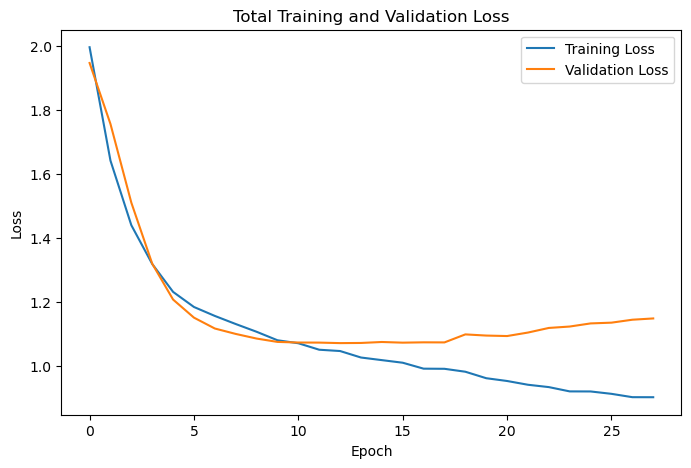

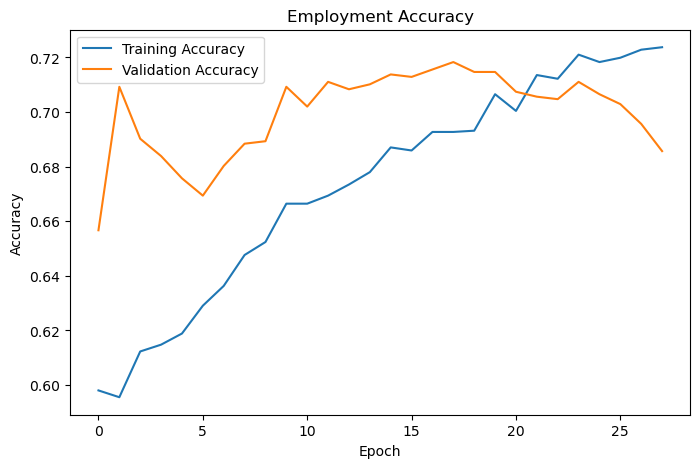

In [15]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Total Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

if "employment_output_accuracy" in history_df:
    plt.figure(figsize=(8, 5))
    plt.plot(
        history_df["employment_output_accuracy"],
        label="Training Accuracy",
    )
    plt.plot(
        history_df["val_employment_output_accuracy"],
        label="Validation Accuracy",
    )
    plt.title("Employment Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

## 16. Evaluate employment prediction

The employment threshold is selected using the validation set only. The test set remains untouched until the final evaluation.

The selected threshold maximizes macro F1, which gives both employed and not-employed classes meaningful consideration.

In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score

validation_predictions = multitask_model.predict(
    X_validation,
    verbose=0,
)

validation_employment_probability = validation_predictions[
    "employment_output"
].reshape(-1)

validation_employment_true = y_employment[
    validation_indices
].astype(int)

threshold_records = []

for threshold in np.arange(0.20, 0.81, 0.01):
    validation_employment_prediction = (
        validation_employment_probability >= threshold
    ).astype(int)

    threshold_records.append(
        {
            "threshold": round(float(threshold), 2),
            "macro_f1": f1_score(
                validation_employment_true,
                validation_employment_prediction,
                average="macro",
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                validation_employment_true,
                validation_employment_prediction,
            ),
            "precision_employed": precision_score(
                validation_employment_true,
                validation_employment_prediction,
                zero_division=0,
            ),
            "recall_employed": recall_score(
                validation_employment_true,
                validation_employment_prediction,
                zero_division=0,
            ),
        }
    )

best_employment_threshold = 0.40

print(
    f"Using employment threshold: "
    f"{best_employment_threshold:.2f}"
)

predictions = multitask_model.predict(
    X_test,
    verbose=0,
)

employment_probability = predictions[
    "employment_output"
].reshape(-1)

employment_prediction = (
    employment_probability >= best_employment_threshold
).astype(int)

employment_true = y_employment[
    test_indices
].astype(int)

print(
    classification_report(
        employment_true,
        employment_prediction,
        target_names=["Not Employed", "Employed"],
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        employment_true,
        employment_prediction,
    )
)

employment_accuracy = accuracy_score(
    employment_true,
    employment_prediction,
)

employment_macro_f1 = f1_score(
    employment_true,
    employment_prediction,
    average="macro",
    zero_division=0,
)

print(f"Test accuracy: {employment_accuracy:.4f}")
print(f"Test macro F1: {employment_macro_f1:.4f}")

Using employment threshold: 0.40
              precision    recall  f1-score   support

Not Employed     0.3811    0.4934    0.4300       302
    Employed     0.8453    0.7755    0.8089      1078

    accuracy                         0.7138      1380
   macro avg     0.6132    0.6344    0.6195      1380
weighted avg     0.7437    0.7138    0.7260      1380

Confusion matrix:
[[149 153]
 [242 836]]
Test accuracy: 0.7138
Test macro F1: 0.6195


## 17. Evaluate income prediction

In [18]:
income_prediction_scaled = predictions["income_output"]

income_prediction_log = income_scaler.inverse_transform(
    income_prediction_scaled
)

income_prediction = np.expm1(
    income_prediction_log
).reshape(-1)

income_true = df.iloc[test_indices][TARGET_INCOME].to_numpy()
employed_test_mask = employment_true == 1

income_mae = mean_absolute_error(
    income_true[employed_test_mask],
    income_prediction[employed_test_mask],
)

income_rmse = mean_squared_error(
    income_true[employed_test_mask],
    income_prediction[employed_test_mask],
) ** 0.5

income_r2 = r2_score(
    income_true[employed_test_mask],
    income_prediction[employed_test_mask],
)

print(f"MAE:  ${income_mae:,.2f}")
print(f"RMSE: ${income_rmse:,.2f}")
print(f"R²:   {income_r2:.4f}")

MAE:  $14,052.20
RMSE: $18,952.97
R²:   0.6339


## 18. Evaluate employment-category prediction

The category head is evaluated only on employed test rows.

The classification report shows precision, recall and F1-score. The normalized confusion matrix shows which employment categories are being confused with one another.

                                         precision    recall  f1-score   support

             Arts, Culture & Recreation     0.4286    1.0000    0.6000        12
     Business, Finance & Administration     0.6667    0.9565    0.7857        69
       Education, Law & Social Services     0.5672    0.8444    0.6786        45
                                 Health     0.5563    0.9753    0.7085        81
                             Management     0.5781    1.0000    0.7327        37
              Manufacturing & Utilities     0.4863    0.3622    0.4152       196
             Natural & Applied Sciences     0.6860    0.9793    0.8068       145
                        Sales & Service     0.6161    0.4452    0.5169       292
Trades, Transport & Equipment Operators     0.6842    0.3881    0.4952       201

                               accuracy                         0.6058      1078
                              macro avg     0.5855    0.7723    0.6377      1078
                          

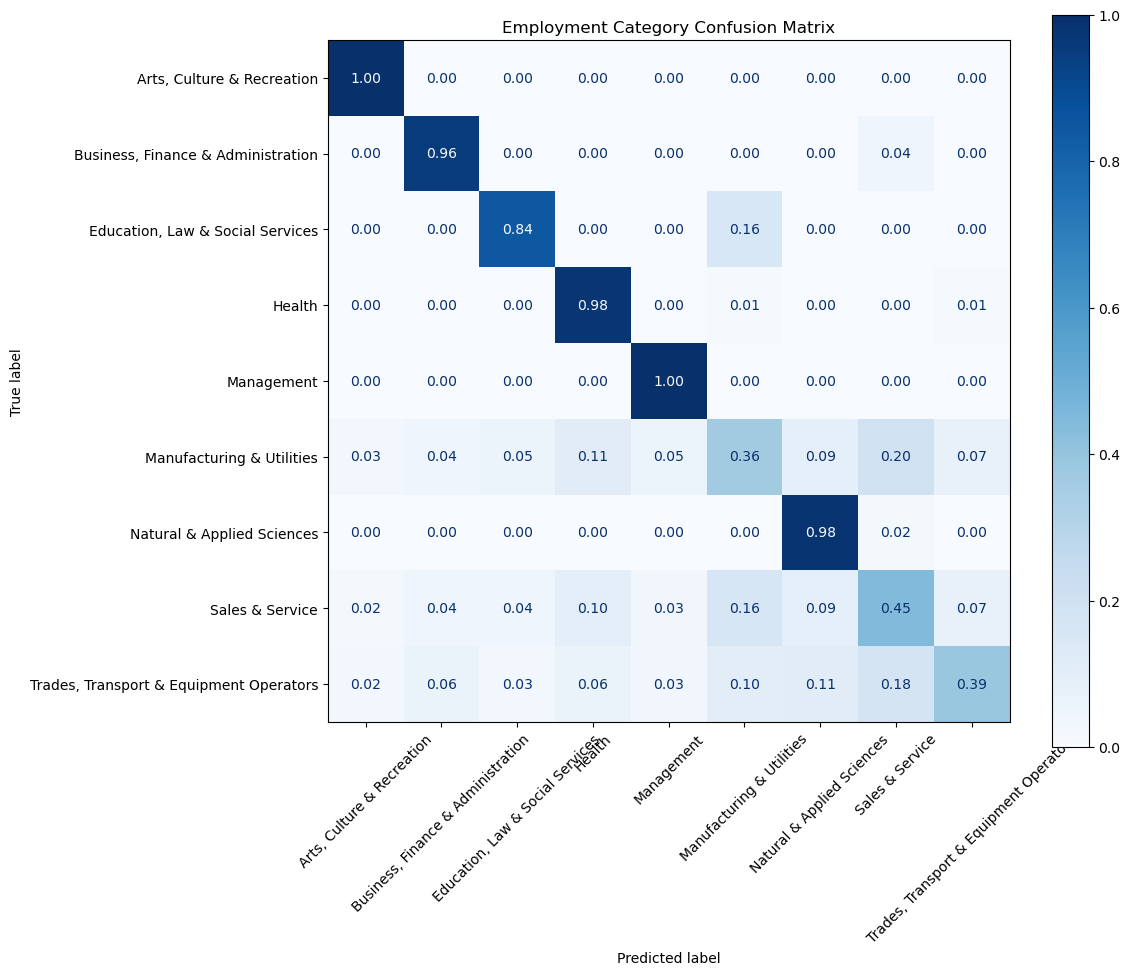

In [19]:
category_prediction_all = np.argmax(
    predictions["category_output"],
    axis=1,
)

# Evaluate employment category only for employed test rows.
test_employed_mask = (
    y_employment[test_indices] == 1
)

category_prediction = category_prediction_all[
    test_employed_mask
]

category_true = y_category_integer[
    test_indices[test_employed_mask]
]

print(
    classification_report(
        category_true,
        category_prediction,
        labels=np.arange(number_of_categories),
        target_names=category_encoder.classes_,
        digits=4,
        zero_division=0,
    )
)

# The confusion matrix shows which categories are commonly mixed up.
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    category_true,
    category_prediction,
    labels=np.arange(number_of_categories),
    display_labels=category_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues",
    normalize="true",
    values_format=".2f",
    ax=ax,
)

plt.title("Employment Category Confusion Matrix")
plt.tight_layout()
plt.show()

## 18.1 Save a compact Version 1.1 results table

This table will make the later comparison with Version 1.0 easier.

In [20]:
category_accuracy = accuracy_score(
    category_true,
    category_prediction,
)

version_1_1_results = pd.DataFrame(
    [
        {
            "model_version": "ProfileEncoder 1.1",
            "employment_threshold": best_employment_threshold,
            "employment_accuracy": employment_accuracy,
            "employment_macro_f1": employment_macro_f1,
            "income_mae": income_mae,
            "income_rmse": income_rmse,
            "income_r2": income_r2,
            "category_accuracy": category_accuracy,
        }
    ]
)

print("Version 1.1 test results:")
display(version_1_1_results.round(4))

version_1_1_results.to_csv(
    "profile_encoder_v1_1_test_results.csv",
    index=False,
)

Version 1.1 test results:


,model_version,employment_threshold,employment_accuracy,employment_macro_f1,income_mae,income_rmse,income_r2,category_accuracy
0,ProfileEncoder 1.1,0.4,0.7138,0.6195,14052.1959,18952.9652,0.6339,0.6058


## 19. Create and inspect the improved ProfileEncoder

The output remains a 16-dimensional vector. Because Version 1.1 does not use `tanh`, the analysis focuses on active dimensions, spread, extreme values, and uniqueness rather than tanh saturation.

In [21]:
profile_encoder = keras.Model(
    inputs=multitask_model.input,
    outputs=multitask_model.get_layer(
        "profile_embedding"
    ).output,
    name="profile_encoder_v1_1",
)

profile_encoder.summary()

test_embeddings = profile_encoder.predict(
    X_test,
    verbose=0,
)

print("Embedding shape:", test_embeddings.shape)
print("\nFirst embedding:")
print(test_embeddings[0])

embedding_summary = pd.DataFrame(
    {
        "dimension": np.arange(
            1,
            test_embeddings.shape[1] + 1,
        ),
        "mean": test_embeddings.mean(axis=0),
        "standard_deviation": test_embeddings.std(axis=0),
        "minimum": test_embeddings.min(axis=0),
        "maximum": test_embeddings.max(axis=0),
    }
)

print("\nEmbedding summary by dimension:")
display(embedding_summary.round(4))

nearly_constant_dimensions = (
    embedding_summary["standard_deviation"] < 0.01
).sum()

extreme_value_rate = (
    np.abs(test_embeddings) > 3.0
).mean()

rounded_embeddings = np.round(
    test_embeddings,
    decimals=6,
)

unique_embedding_count = np.unique(
    rounded_embeddings,
    axis=0,
).shape[0]

duplicate_rate = (
    1
    - unique_embedding_count / len(rounded_embeddings)
)

print(
    f"\nNearly constant embedding dimensions: "
    f"{nearly_constant_dimensions} out of "
    f"{test_embeddings.shape[1]}"
)

print(
    f"Values with absolute magnitude above 3: "
    f"{extreme_value_rate:.2%}"
)

print(
    f"Unique test embeddings: "
    f"{unique_embedding_count:,} out of "
    f"{len(test_embeddings):,}"
)

print(f"Duplicate rate: {duplicate_rate:.2%}")

Model: "profile_encoder_v1_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ processed_profile_… │ (None, 116)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input_slice │ (None, 5)         │          0 │ processed_profil… │
│ (FeatureSlice)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_input_… │ (None, 111)       │          0 │ processed_profil… │
│ (FeatureSlice)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dense_32    │ (None, 32)        │        192 │ numeric_input_sl… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_dense_… │ (None, 128)       │     14,336 │ categorical_inpu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_batch_norm  │ (None, 32)        │        128 │ numeric_dense_32… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_batch_… │ (None, 128)       │        512 │ categorical_dens… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dropout     │ (None, 32)        │          0 │ numeric_batch_no… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_dropout │ (None, 128)       │          0 │ categorical_batc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_dense_16    │ (None, 16)        │        528 │ numeric_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_dense_… │ (None, 64)        │      8,256 │ categorical_drop… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_profile_f… │ (None, 80)        │          0 │ numeric_dense_16… │
│ (Concatenate)       │                   │            │ categorical_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_64     │ (None, 64)        │      5,184 │ combined_profile… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_batch_norm   │ (None, 64)        │        256 │ shared_dense_64[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 64)        │          0 │ shared_batch_nor… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_32     │ (None, 32)        │      2,080 │ shared_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ profile_embedding_… │ (None, 16)        │        528 │ shared_dense_32[

 Total params: 32,064 (125.25 KB)

 Trainable params: 31,584 (123.38 KB)

 Non-trainable params: 480 (1.88 KB)

Embedding shape: (1380, 16)

First embedding:
[ 2.017348   -1.4002081  -1.0217199  -0.1119757   1.6242499   0.05996597
  0.5916224   0.01036783 -1.5685614   0.8300736   1.8449587  -0.03007347
 -0.32000726  1.3247793  -0.08362583 -1.6356199 ]

Embedding summary by dimension:


,dimension,mean,standard_deviation,minimum,maximum
0,1,-0.0680,1.0370,-2.0668,4.0733
1,2,-0.0438,1.0437,-4.0838,2.6734
2,3,0.2290,1.0198,-3.9930,2.2446
3,4,-0.0546,1.0827,-2.6159,3.8208
4,5,0.0379,1.0519,-4.0740,2.1085
5,6,-0.1683,1.0722,-2.1046,3.8391
6,7,0.2084,0.9857,-3.0924,2.5351
7,8,0.0713,1.1002,-2.8779,4.4307
8,9,-0.0935,1.0881,-2.4970,2.6657
9,10,-0.0014,0.9725,-2.4215,3.5762



Nearly constant embedding dimensions: 0 out of 16
Values with absolute magnitude above 3: 0.93%
Unique test embeddings: 1,380 out of 1,380
Duplicate rate: 0.00%


## 20. Save the improved ProfileEncoder pipeline

In [22]:
profile_encoder.save(
    "profile_encoder_v1_1.keras"
)

multitask_model.save(
    "profile_multitask_model_v1_1.keras"
)

joblib.dump(
    preprocessor,
    "profile_encoder_preprocessor_v1_1.joblib",
)

joblib.dump(
    income_scaler,
    "profile_encoder_income_scaler_v1_1.joblib",
)

joblib.dump(
    category_encoder,
    "profile_encoder_category_encoder_v1_1.joblib",
)

model_config = {
    "version": "1.1",
    "features": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "embedding_size": 16,
    "embedding_activation": "linear_with_batch_normalization",
    "employment_threshold": best_employment_threshold,
    "loss_weights": {
        "employment_output": 1.0,
        "income_output": 0.5,
        "category_output": 0.6,
    },
    "employment_categories": (
        category_encoder.classes_.tolist()
    ),
}

with open(
    "profile_encoder_config_v1_1.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(model_config, file, indent=2)

print("Saved profile_encoder_v1_1.keras")
print("Saved profile_multitask_model_v1_1.keras")
print("Saved profile_encoder_preprocessor_v1_1.joblib")
print("Saved profile_encoder_income_scaler_v1_1.joblib")
print("Saved profile_encoder_category_encoder_v1_1.joblib")
print("Saved profile_encoder_config_v1_1.json")

Saved profile_encoder_v1_1.keras
Saved profile_multitask_model_v1_1.keras
Saved profile_encoder_preprocessor_v1_1.joblib
Saved profile_encoder_income_scaler_v1_1.joblib
Saved profile_encoder_category_encoder_v1_1.joblib
Saved profile_encoder_config_v1_1.json


In [23]:
# Verify that the saved encoder can be loaded in a fresh step.
reloaded_profile_encoder = keras.models.load_model(
    "profile_encoder_v1_1.keras",
    custom_objects={
        "FeatureSlice": FeatureSlice,
    },
    compile=False,
)

verification_embeddings = (
    reloaded_profile_encoder.predict(
        X_test[:5],
        verbose=0,
    )
)

print(
    "Reload verification passed. Shape:",
    verification_embeddings.shape,
)

Reload verification passed. Shape: (5, 16)


## 21. Test the improved encoder with one sample user

This is similar to what will happen when a real user submits the Streamlit form.

The values in this example must use categories that match the training dataset.

In [24]:
sample_user = pd.DataFrame(
    [
        {
            "age": 32,
            "sex": "F",
            "admission_category": "Skilled Worker",
            "world_region": "South Asia",
            "speaks_official_language": 1,
            "education_level": "University",
            "family_size": 2,
            "field_of_study": "Computer Science",
            "previous_occupation": "Data Analyst",
            "occupation_category": "Natural & Applied Sciences",
            "years_of_experience": 6,
            "teer_category": "TEER 1",
            "credential_recognition_status": "Fully Recognized",
            "regulated_profession": 0,
        }
    ]
)

sample_user_processed = preprocessor.transform(
    sample_user
).astype("float32")

sample_embedding = profile_encoder.predict(
    sample_user_processed,
    verbose=0,
)

print("Embedding shape:", sample_embedding.shape)
print("User profile embedding:")
print(sample_embedding[0])

Embedding shape: (1, 16)
User profile embedding:
[ 1.1237454  -0.63482916 -0.35361832 -0.12282968  1.685828   -0.48669007
  1.7581487  -0.46649963 -2.1169999   0.149768    2.070019   -0.36943254
 -0.88748956  1.4494784  -0.31706464 -0.95005214]


## 22. How this will be used later

During development:

```text
Enriched dataset
        ↓
Train multi-task neural network
        ↓
Save ProfileEncoder
```

During app use:

```text
User background form
        ↓
Saved preprocessing
        ↓
Saved ProfileEncoder
        ↓
16-value embedding
        ↓
Recommendation engine
```

The recommendation engine will combine this embedding with XGBoost predictions, user preferences and Adzuna job information.

## 18. Export recommendation-engine inputs

This section prepares one integration table for the recommendation engine. It contains a stable user identifier, the 16 ProfileEncoder dimensions, the employment probability, the predicted annual income, and the predicted occupation.

The table is created for every profile in the dataset and saved as:

`profile_encoder_recommendation_inputs_v1_1.csv`

For users predicted as not employed at the selected threshold, the predicted occupation is recorded as `Not Employed`.

In [25]:
# Process every newcomer profile using the fitted preprocessor.
all_profiles_processed = preprocessor.transform(
    df[FEATURES]
).astype("float32")

# Generate the 16-dimensional profile embeddings.
all_embeddings = profile_encoder.predict(
    all_profiles_processed,
    verbose=0,
)

# Generate the three multitask-model predictions.
all_predictions = multitask_model.predict(
    all_profiles_processed,
    verbose=0,
)

# Employment probability and threshold-based class.
all_employment_probability = all_predictions[
    "employment_output"
].reshape(-1)

all_employment_prediction = (
    all_employment_probability >= best_employment_threshold
).astype(int)

# Convert the scaled log-income prediction back to annual dollars.
all_income_prediction_log = income_scaler.inverse_transform(
    all_predictions["income_output"]
)

all_predicted_income = np.expm1(
    all_income_prediction_log
).reshape(-1)

# Avoid negative income values after inverse transformation.
all_predicted_income = np.maximum(
    all_predicted_income,
    0
)

# Decode the predicted employment occupation.
all_category_indices = np.argmax(
    all_predictions["category_output"],
    axis=1,
)

all_predicted_occupation = category_encoder.inverse_transform(
    all_category_indices
).astype(object)

# The employment head determines whether an occupation should be assigned.
all_predicted_occupation[
    all_employment_prediction == 0
] = "Not Employed"

# Use an existing ID column when available. Otherwise, create a stable ID.
possible_id_columns = [
    "UserID",
    "user_id",
    "NewcomerID",
    "newcomer_id",
    "ID",
    "id",
]

user_id_column = next(
    (
        column
        for column in possible_id_columns
        if column in df.columns
    ),
    None,
)

if user_id_column is not None:
    exported_user_ids = df[user_id_column].astype(str).to_numpy()
    print(f"Using existing ID column: {user_id_column}")
else:
    exported_user_ids = np.array(
        [
            f"NEWCOMER_{index:05d}"
            for index in range(1, len(df) + 1)
        ]
    )
    print("No ID column was found, so stable UserID values were created.")

# Build clearly named embedding columns.
embedding_columns = [
    f"Embedding_{index}"
    for index in range(1, all_embeddings.shape[1] + 1)
]

embedding_df = pd.DataFrame(
    all_embeddings,
    columns=embedding_columns,
)

recommendation_inputs = pd.DataFrame(
    {
        "UserID": exported_user_ids,
        "EmploymentProbability": all_employment_probability,
        "PredictedEmployment": all_employment_prediction,
        "PredictedIncome": all_predicted_income,
        "PredictedOccupation": all_predicted_occupation,
    }
)

recommendation_inputs = pd.concat(
    [
        recommendation_inputs.reset_index(drop=True),
        embedding_df.reset_index(drop=True),
    ],
    axis=1,
)

# Round only for the exported integration table.
recommendation_inputs["EmploymentProbability"] = (
    recommendation_inputs["EmploymentProbability"].round(6)
)

recommendation_inputs["PredictedIncome"] = (
    recommendation_inputs["PredictedIncome"].round(2)
)

recommendation_inputs[embedding_columns] = (
    recommendation_inputs[embedding_columns].round(6)
)

recommendation_inputs.to_csv(
    "profile_encoder_recommendation_inputs_v1_1.csv",
    index=False,
)

print(
    "Saved profile_encoder_recommendation_inputs_v1_1.csv"
)
print("Export shape:", recommendation_inputs.shape)

display(recommendation_inputs.head())

No ID column was found, so stable UserID values were created.
Saved profile_encoder_recommendation_inputs_v1_1.csv
Export shape: (6900, 21)


,UserID,EmploymentProbability,PredictedEmployment,PredictedIncome,PredictedOccupation,Embedding_1,Embedding_2,Embedding_3,Embedding_4,Embedding_5,Embedding_6,Embedding_7,Embedding_8,Embedding_9,Embedding_10,Embedding_11,Embedding_12,Embedding_13,Embedding_14,Embedding_15,Embedding_16
0,NEWCOMER_00001,0.760172,1,50616.238281,"Business, Finance & Administration",0.664974,-0.042839,0.564481,-1.373516,0.833938,0.273986,-0.117778,1.373066,-0.580375,1.253726,-0.779829,0.650246,-1.152054,0.183355,-1.455121,-0.384349
1,NEWCOMER_00002,0.525596,1,70505.937500,"Business, Finance & Administration",3.136782,-1.972869,-1.319131,-0.817113,0.313716,2.395938,-0.742114,1.748380,-0.405365,2.528562,-0.919047,1.935379,1.009355,0.231992,-0.376695,-1.951083
2,NEWCOMER_00003,0.624963,1,85653.828125,"Business, Finance & Administration",2.414502,-1.588804,-1.092570,-1.167388,0.531761,1.888591,0.358459,2.160273,-0.561223,2.934484,-0.747369,1.549788,0.335630,0.228521,-0.613119,-1.629671
3,NEWCOMER_00004,0.577074,1,85728.523438,Management,-0.859219,-1.263327,-2.482215,0.906005,-3.043944,1.079318,-1.797297,0.937107,0.224804,-0.534605,0.585003,3.027274,1.527878,2.416512,1.714735,0.873021
4,NEWCOMER_00005,0.828762,1,46903.359375,Sales & Service,0.348049,-0.360923,0.985284,-0.006780,0.711043,-1.156930,1.240179,-0.154098,-0.866784,-0.202216,0.583882,-0.766529,-1.369090,0.593811,-0.885244,-0.294967


### Recommendation-engine integration note

The recommendation engine should load the saved model files for a new Streamlit user rather than search for that user in the exported CSV. The CSV is useful for testing, evaluation, demonstrations, and batch recommendations.

For a new user, the production flow is:

1. collect the same 14 input features;
2. transform them with `profile_encoder_preprocessor_v1_1.joblib`;
3. generate the 16-dimensional embedding with `profile_encoder_v1_1.keras`;
4. obtain employment, income, and occupation predictions from `profile_multitask_model_v1_1.keras`;
5. combine these outputs with Adzuna job information and user preferences in the ranking formula.

## Final note

Version 1.1 is an experiment, not an automatic replacement for Version 1.0.

After running this notebook, compare the following with the baseline:

- employment accuracy, recall, macro F1, and confusion matrix;
- income MAE, RMSE, and R²;
- employment-category accuracy and class-level results;
- number of active embedding dimensions;
- duplicate embedding rate;
- nearest-neighbour quality;
- within-group and across-group cosine similarity;
- influence of numerical features;
- the absence of the original tanh saturation problem.

Version 1.1 should replace Version 1.0 only if the overall recommendation representation improves without causing unacceptable prediction losses.